In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
def moving_average(data_01, window_size):
    window = np.ones(int(window_size))/float(window_size)
    return np.convolve(data_01, window, 'same')

In [16]:
# Filter input
window_size=300
slice_index=160  

In [17]:
# Set paths to file location
data_path_01="/Users/josephgiliberto/Builds/NGA2/examples/simplex/test_data/smp_01"
data_path_02="/Users/josephgiliberto/Builds/NGA2/examples/simplex/test_data/smp_02"
data_path_06="/Users/josephgiliberto/Builds/NGA2/examples/simplex/test_data/smp_06"

# Import data_01
data_01=pd.DataFrame({'time':np.genfromtxt(data_path_01,skip_header=2,usecols=1),
                   'time_step_size':np.genfromtxt(data_path_01,skip_header=2,usecols=2),
                   'Pmax':np.genfromtxt(data_path_01,skip_header=2,usecols=7),
                   'vof_integral':np.genfromtxt(data_path_01,skip_header=2,usecols=8),
                   'vof_removed':np.genfromtxt(data_path_01,skip_header=2,usecols=9)})
data_02=pd.DataFrame({'time':np.genfromtxt(data_path_02,skip_header=2,usecols=1),
                   'time_step_size':np.genfromtxt(data_path_02,skip_header=2,usecols=2),
                   'Pmax':np.genfromtxt(data_path_02,skip_header=2,usecols=7),
                   'vof_integral':np.genfromtxt(data_path_02,skip_header=2,usecols=8),
                   'vof_removed':np.genfromtxt(data_path_02,skip_header=2,usecols=9)})
data_06=pd.DataFrame({'time':np.genfromtxt(data_path_06,skip_header=2,usecols=1),
                   'time_step_size':np.genfromtxt(data_path_06,skip_header=2,usecols=2),
                   'Pmax':np.genfromtxt(data_path_06,skip_header=2,usecols=7),
                   'vof_integral':np.genfromtxt(data_path_06,skip_header=2,usecols=8),
                   'vof_removed':np.genfromtxt(data_path_06,skip_header=2,usecols=9)})

FileNotFoundError: /Users/josephgiliberto/Builds/NGA2/examples/simplex/test_data/smp_01 not found.

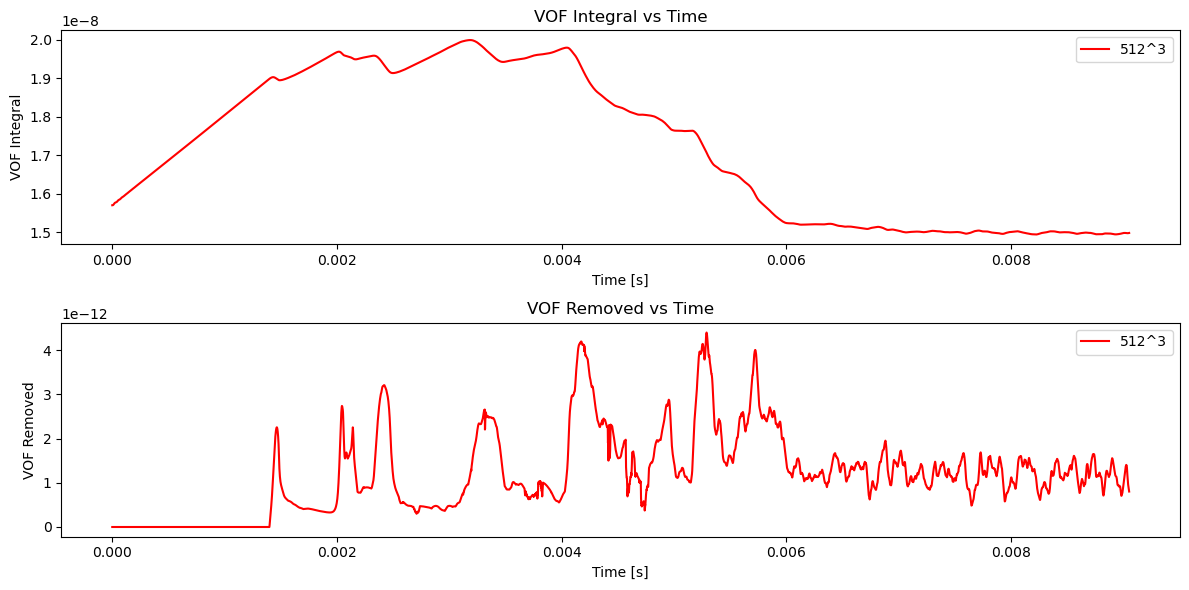

In [ ]:
# Apply the low pass filter
filtered_signal_integral = moving_average(data_01.vof_integral, window_size)
filtered_signal_removed = moving_average(data_01.vof_removed, window_size)

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
# plt.plot(data_01.time, data_01.vof_integral, label='pre hypre update/vof removal', color='blue')
# plt.plot(data_02.time, data_02.vof_integral, label='post hypre update/vof removal', color='orange')
plt.plot(data_06.time, data_06.vof_integral, label='512^3', color='red')
# plt.plot(data_01.time[slice_index:-slice_index], filtered_signal_integral[slice_index:-slice_index], label='Filtered', color='orange')
plt.title('VOF Integral vs Time')
plt.xlabel('Time [s]')
plt.ylabel('VOF Integral')
plt.legend()

plt.subplot(2, 1, 2)
# plt.plot(data_01.time, data_01.vof_removed, label='pre hypre update/vof removal', color='blue')
# plt.plot(data_02.time, data_02.vof_removed, label='post hypre update/vof removal', color='orange')
plt.plot(data_06.time, data_06.vof_removed, label='512^3', color='red')
# plt.plot(data_01.time[slice_index:-slice_index], filtered_signal_removed[slice_index:-slice_index], label='Filtered', color='orange')
plt.title('VOF Removed vs Time')
plt.xlabel('Time [s]')
plt.ylabel('VOF Removed')
plt.legend()
plt.tight_layout()
plt.show()

## Approximate flow rate out of domain through VOF removed

(0.0, 0.009)

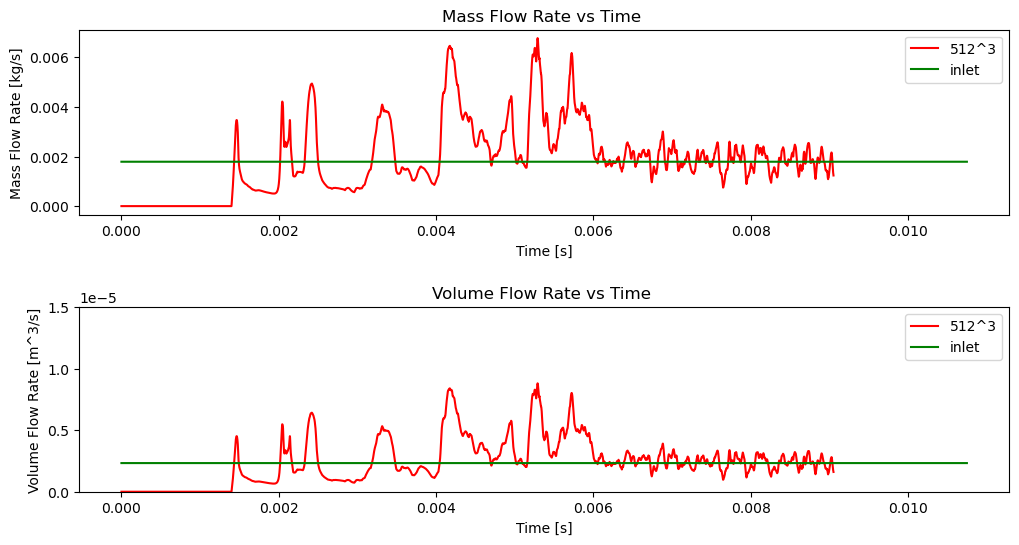

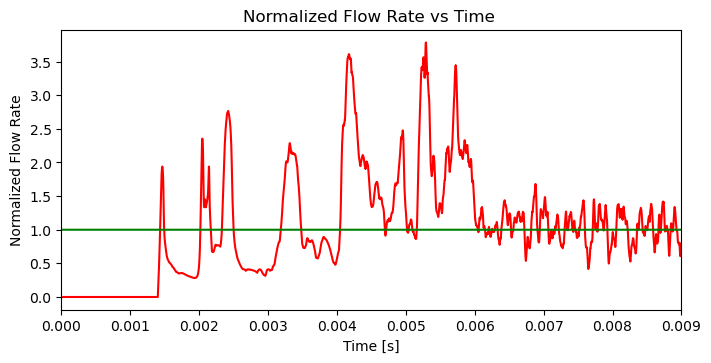

In [ ]:
# Convert VOF removed to mass flow rate in kg/s
rho_l          = 770 # (kg/m^3) density of water
# vol_removed    = filtered_signal_removed[slice_index:-slice_index] # (m^3)  volume of liquid being removed with time
vol_flow_rate_01  = data_01.vof_removed/data_01.time_step_size # (m^3/s) volume flow rate at of the liquid being removed
mass_flow_rate_01 = vol_flow_rate_01*rho_l # (kg/s) mass flow rate of the water being removed
vol_flow_rate_02  = data_02.vof_removed/data_02.time_step_size # (m^3/s) volume flow rate at of the liquid being removed
mass_flow_rate_02 = vol_flow_rate_02*rho_l # (kg/s) mass flow rate of the water being removed
vol_flow_rate_06  = data_06.vof_removed/data_06.time_step_size # (m^3/s) volume flow rate at of the liquid being removed
mass_flow_rate_06 = vol_flow_rate_06*rho_l # (kg/s) mass flow rate of the water being removed

# Prescribed mass inflow 
mfr           = 1.79e-3 # (kg/s) mass flow rate being imposed at the inlet
vol_fr        = mfr/rho_l # (m^3/s) volume flow rate being imposed at the inlet 
mfr_inflow    = mfr*np.ones(len(mass_flow_rate_01))
vol_fr_inflow = vol_fr*np.ones(len(vol_flow_rate_01))
norm_fr_inflow = np.ones(len(vol_flow_rate_01))

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
# plt.plot(data_01.time, mass_flow_rate_01, label='pre hypre update/vof removal', color='blue')
# plt.plot(data_02.time, mass_flow_rate_02, label='post hypre update/vof removal', color='orange')
plt.plot(data_06.time, mass_flow_rate_06, label='512^3', color='red')
plt.plot(data_01.time, mfr_inflow , label='inlet', color='green')
plt.title('Mass Flow Rate vs Time ')
plt.xlabel('Time [s]')
plt.ylabel('Mass Flow Rate [kg/s]')
# plt.ylim(0, 5)
plt.legend()

plt.subplots_adjust(hspace=0.5)

plt.subplot(2, 1, 2)
# plt.plot(data_01.time, vol_flow_rate_01, label='pre hypre update/vof removal', color='blue')
# plt.plot(data_02.time, vol_flow_rate_02, label='post hypre update/vof removal', color='orange')
plt.plot(data_06.time, vol_flow_rate_06, label='512^3', color='red')
plt.plot(data_01.time, vol_fr_inflow , label='inlet', color='green')
plt.title('Volume Flow Rate vs Time ')
plt.xlabel('Time [s]')
plt.ylabel('Volume Flow Rate [m^3/s]')
plt.ylim(0, 1.5e-5)
plt.legend()

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
# plt.plot(data_01.time, vol_flow_rate_01/vol_fr, label='pre hypre update/vof removal', color='blue')
# plt.plot(data_02.time, vol_flow_rate_02/vol_fr, label='post hypre update/vof removal', color='orange')
plt.plot(data_06.time, vol_flow_rate_06/vol_fr, label='512^3', color='red')
plt.plot(data_01.time, norm_fr_inflow, color='green')
plt.title('Normalized Flow Rate vs Time ')
plt.xlabel('Time [s]')
plt.ylabel('Normalized Flow Rate')
plt.xlim(0, 9e-3)
# plt.legend()

## Plot maximum pressure

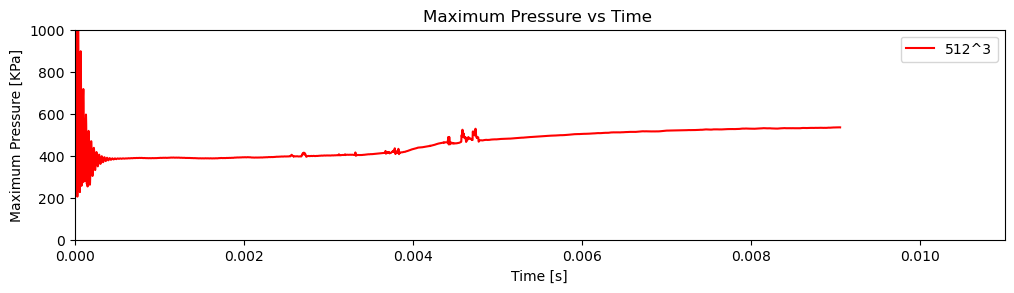

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
# plt.plot(data_01.time, data_01.Pmax/1000.0, label='pre hypre update/vof removal', color='blue')
# plt.plot(data_02.time, data_02.Pmax/1000.0, label='post hypre update/vof removal', color='orange')
plt.plot(data_06.time, data_06.Pmax/1000.0, label='512^3', color='red')
plt.title('Maximum Pressure vs Time ')
plt.xlabel('Time [s]')
plt.ylabel('Maximum Pressure [KPa]')
plt.xlim(0, 0.011)
plt.ylim(0, 1000)
plt.legend()

# plt.subplots_adjust(hspace=0.5)

# plt.subplot(2, 1, 2)
# plt.plot(data_01.time, data_01.Pmax/6895.0, label='pre hypre update/vof removal', color='blue')
# plt.plot(data_02.time, data_02.Pmax/6895.0, label='post hypre update/vof removal', color='orange')
# plt.title('Maximum Pressure vs Time ')
# plt.xlabel('Time [s]')
# plt.ylabel('Maximum Pressure [psi]')
# plt.ylim(0, 200)
# plt.legend()

## Plot Timing info

In [ ]:
# # Set paths to file location
# data_path_06_time="/Users/josephgiliberto/Builds/NGA2/examples/simplex/test_data/timing_06"
# data_path_09_time="/Users/josephgiliberto/Builds/NGA2/examples/simplex/test_data/timing_09"

# # Import data_06
# data_timing_06=pd.DataFrame({'timestep_number':np.genfromtxt(data_path_06_time,skip_header=2,usecols=0),
#                              'Timestep':np.genfromtxt(data_path_06_time,skip_header=2,usecols=2),
#                              'VOFSolve':np.genfromtxt(data_path_06_time,skip_header=2,usecols=3),
#                              'Velocity':np.genfromtxt(data_path_06_time,skip_header=2,usecols=4),
#                              'Pressure':np.genfromtxt(data_path_06_time,skip_header=2,usecols=5),
#                              'SGSmodel':np.genfromtxt(data_path_06_time,skip_header=2,usecols=6),
#                              'Transfer':np.genfromtxt(data_path_06_time,skip_header=2,usecols=7)})
# # Import data_09
# data_timing_09=pd.DataFrame({'timestep_number':np.genfromtxt(data_path_09_time,skip_header=2,usecols=0),
#                              'Timestep':np.genfromtxt(data_path_09_time,skip_header=2,usecols=2),
#                              'VOFSolve':np.genfromtxt(data_path_09_time,skip_header=2,usecols=3),
#                              'Velocity':np.genfromtxt(data_path_09_time,skip_header=2,usecols=4),
#                              'Pressure':np.genfromtxt(data_path_09_time,skip_header=2,usecols=5),
#                              'SGSmodel':np.genfromtxt(data_path_09_time,skip_header=2,usecols=6),
#                              'Transfer':np.genfromtxt(data_path_09_time,skip_header=2,usecols=7)})

In [ ]:
# plt.figure(figsize=(8, 10))
# plt.subplot(2, 1, 1)
# plt.scatter(data_timing_06.timestep_number, data_timing_06.Velocity, label='Velocity', color='red')
# plt.scatter(data_timing_06.timestep_number, data_timing_06.VOFSolve, label='VOFsolve', color='green')
# plt.scatter(data_timing_06.timestep_number, data_timing_06.Pressure, label='Pressure', color='blue')
# plt.title('Implicit Velocity Solver ')
# plt.xlabel('Timestep number')
# plt.ylabel('Time [s]')
# plt.ylim(0, 10)
# plt.legend()

# plt.figure(figsize=(8, 10))
# plt.subplot(2, 1, 1)
# plt.scatter(data_timing_09.timestep_number, data_timing_09.Velocity, label='Velocity', color='red')
# plt.scatter(data_timing_09.timestep_number, data_timing_09.VOFSolve, label='VOFsolve', color='green')
# plt.scatter(data_timing_09.timestep_number, data_timing_09.Pressure, label='Pressure', color='blue')
# plt.title('Explicit Velocity Solver ')
# plt.xlabel('Timestep number')
# plt.ylabel('Time [s]')
# plt.ylim(0, 10)
# plt.legend()

# # Time step
# time_step_sum=np.sum(data_timing_09.Timestep)
# num_steps=6240.0
# avg=time_step_sum/num_steps
# # print(avg)
# num_step_imp=18472
# time_total=avg*num_step_imp
# time_total_hours = time_total/3600
# # print(time_total_hours)
# core_hours = 75*12*time_total_hours
# print(core_hours)

In [19]:
# Set paths to file location
data_path_05_time="/Users/josephgiliberto/Builds/NGA2/examples/simplex_old/test_data_11112024/05_smpx_timing"
data_path_06_time="/Users/josephgiliberto/Builds/NGA2/examples/simplex_old/test_data_11112024/06_smpx_timing"

# Import data_05
data_timing_05=pd.DataFrame({'timestep_number':np.genfromtxt(data_path_05_time,skip_header=2,usecols=0),
                             'Timestep':np.genfromtxt(data_path_05_time,skip_header=2,usecols=2),
                             'VOFSolve':np.genfromtxt(data_path_05_time,skip_header=2,usecols=3),
                             'Velocity':np.genfromtxt(data_path_05_time,skip_header=2,usecols=4),
                             'Pressure':np.genfromtxt(data_path_05_time,skip_header=2,usecols=5),
                             'SGSmodel':np.genfromtxt(data_path_05_time,skip_header=2,usecols=6),
                             'Transfer':np.genfromtxt(data_path_05_time,skip_header=2,usecols=7)})
# Import data_06
data_timing_06=pd.DataFrame({'timestep_number':np.genfromtxt(data_path_06_time,skip_header=2,usecols=0),
                             'Timestep':np.genfromtxt(data_path_06_time,skip_header=2,usecols=2),
                             'VOFSolve':np.genfromtxt(data_path_06_time,skip_header=2,usecols=3),
                             'Velocity':np.genfromtxt(data_path_06_time,skip_header=2,usecols=4),
                             'Pressure':np.genfromtxt(data_path_06_time,skip_header=2,usecols=5),
                             'SGSmodel':np.genfromtxt(data_path_06_time,skip_header=2,usecols=6),
                             'Transfer':np.genfromtxt(data_path_06_time,skip_header=2,usecols=7)})

In [21]:
# Cost of 2 plane reconstrcuction 
# Time step
time_step_sum=np.sum(data_timing_06.Timestep)
time_total_hours = time_step_sum/3600
# print(time_total_hours)
core_hours = 14*12*time_total_hours
print(core_hours)

4456.929113


In [22]:
# Cost of 1 plane reconstrcuction 
# Time step
time_step_sum=np.sum(data_timing_05.Timestep)
num_steps=22254.0
avg=time_step_sum/num_steps
# print(avg)
num_step_imp=12783
time_total=avg*num_step_imp
time_total_hours = time_total/3600
# print(time_total_hours)
core_hours = 14*12*time_total_hours
print(core_hours)

2020.4966499644017
